##first

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn.functional as F
print(torch.__version__, torch.cuda.is_available())

2.13.0+cpu False


In [2]:
words =open('words.txt', 'r').read().splitlines()
len(words)

7944

In [3]:
chars=sorted(list(set(''.join(words))))
chars = [c for c in chars if c.isalpha()]
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'F', 7: 'G', 8: 'H', 9: 'I', 10: 'J', 11: 'K', 12: 'L', 13: 'M', 14: 'N', 15: 'O', 16: 'P', 17: 'Q', 18: 'R', 19: 'S', 20: 'T', 21: 'U', 22: 'V', 23: 'W', 24: 'X', 25: 'Y', 26: 'Z', 27: 'a', 28: 'b', 29: 'c', 30: 'd', 31: 'e', 32: 'f', 33: 'g', 34: 'h', 35: 'i', 36: 'j', 37: 'k', 38: 'l', 39: 'm', 40: 'n', 41: 'o', 42: 'p', 43: 'q', 44: 'r', 45: 's', 46: 't', 47: 'u', 48: 'v', 49: 'w', 50: 'x', 51: 'y', 52: 'z', 0: '.'}


In [4]:
import matplotlib.pyplot as plt

In [5]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X,Y=[],[]
for w in words:
    
    context = [0] * block_size
    for ch in w + '.':
        if ch not in stoi:
            continue  
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

In [43]:
def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:

        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            if ch not in stoi:
                continue 
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([44617, 3]) torch.Size([44617])
torch.Size([5597, 3]) torch.Size([5597])
torch.Size([5615, 3]) torch.Size([5615])


In [44]:
Xtr.shape , Ytr.shape 


(torch.Size([44617, 3]), torch.Size([44617]))

In [7]:

C = torch.rand(len(stoi), 2)



In [ ]:
emb = C[Xtr]


In [9]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [10]:
h=torch.tanh(emb.view(-1,6) @ W1 + b1)

In [11]:
W2 = torch.randn((100,len(stoi)))
B2 = torch.randn(len(stoi))

In [12]:
logits = h @ W2 + B2

In [13]:
counts = logits.exp()

In [14]:
prob = counts / counts.sum(1, keepdim=True)

In [15]:
loss = -prob[torch.arange(len(Y)), Y].log().mean()
loss

tensor(14.9673)

In [84]:
g=torch.Generator().manual_seed(2147483647)
C = torch.randn((53,10), generator=g , requires_grad=True)
W1 = torch.randn((30,200), generator=g, requires_grad=True)
b1 = torch.randn(200, generator=g, requires_grad=True)
W2 = torch.randn((200,53), generator=g, requires_grad=True)
b2 = torch.randn(53, generator=g, requires_grad=True)
parameters = [C,W1,b1,W2,b2]

In [85]:
sum(p.nelement() for p in parameters)

17383

In [87]:
for p in parameters:
    print(p.shape, p.grad is None)

torch.Size([53, 10]) True
torch.Size([30, 200]) True
torch.Size([200]) True
torch.Size([200, 53]) True
torch.Size([53]) True


In [88]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [101]:
lr_track = []
loss_track = []

for i in range(10000):
    #minipatch
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]]
    h = emb.view(-1, 30)

    h = torch.tanh(h @ W1 + b1)

    logits = h @ W2 + b2

    loss = F.cross_entropy(logits, Ytr[ix])
    print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    # update
    #lr = lrs[i]
    for p in parameters:
        p.data += -0.01 * p.grad
    #lr_track.append(lrs[i])
    #loss_track.append(loss.item())

      

1.6070109605789185
1.857987403869629
2.3926944732666016
2.172001361846924
2.0539867877960205
2.2042441368103027
2.3818774223327637
1.7139012813568115
1.9094055891036987
2.0296452045440674
2.515903949737549
2.0848467350006104
1.9399203062057495
2.087512731552124
2.314088821411133
1.889880895614624
2.1503090858459473
2.3234071731567383
2.5087735652923584
1.850675106048584
2.3326926231384277
1.922877550125122
1.9039640426635742
1.7950416803359985
2.415493965148926
1.6290748119354248
1.9856069087982178
1.7548058032989502
2.3724234104156494
1.8812997341156006
2.777031183242798
1.7087616920471191
2.221466541290283
1.8573312759399414
1.8847570419311523
2.0576553344726562
2.1466739177703857
1.8584411144256592
1.5070946216583252
1.789037823677063
2.3495774269104004
2.200071096420288
1.76881742477417
1.9425978660583496
2.2209107875823975
1.9317927360534668
2.4305317401885986
1.7294766902923584
1.9965900182724
2.1343090534210205
2.2129931449890137
1.8308250904083252
1.9938405752182007
1.788253784

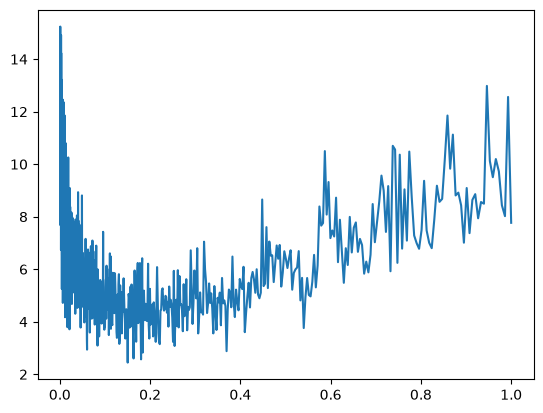

In [93]:
plt.plot(lr_track, loss_track)

In [103]:
emb = C[Xdev]
h =torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1587, grad_fn=<NllLossBackward0>)

In [ ]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size  
    while True:
        emb = C[torch.tensor([context])]   
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print("".join(itos[i] for i in out))

Cobanny.
Stevella.
Ibiormainer.
Wolforrent.
Lobert.
June.
Barb.
Mari.
Bial.
Thuthari.
Avro.
Poych.
Dukfray.
Der.
Sheri.
Keorgee.
Wolfole.
Rick.
Elwi.
Eotte.
